# 17 — Answer Length Bias on Agreement Metrics

**Question:** Do SA-LLMs score lower on HM agreement simply because they produce longer/verbose answers that get penalized by SBERT/chrF/exact match?

nb16 showed length-mismatch penalty in HH pairs (r=-0.42). This notebook extends that to HM pairs:
1. Response length distribution by model group
2. Correlation: response length vs HM agreement (per question×model)
3. Length-controlled comparison: do group differences survive after matching on length?
4. Which metrics are most/least length-biased?

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))
from figures.helpers import save_fig
from utils.constants import GROUP_COLORS, GROUP_ORDER
from config import MODELS_7B

EXPORTS = ROOT / 'analysis/session2/exports'
OUT_DIR = ROOT / 'figures/supplementary/length_bias'
OUT_DIR.mkdir(parents=True, exist_ok=True)

_7b_set = set(MODELS_7B)
VARIANT = 'C'

## 1. Load data & compute response lengths

In [2]:
inst_blind = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
inst_blind = inst_blind[(inst_blind['variant'] == VARIANT) & (inst_blind['model'].isin(_7b_set))].copy()

human_df = pd.read_csv(EXPORTS / 'responses_human.csv')
human_df = human_df[human_df['variant'] == VARIANT].copy()

PAIR_COLS = ['question_id', 'variant', 'pair_type', 'subject_2', 'sbert_score', 'chrf_score']
try:
    pair_cache = pd.read_parquet(EXPORTS / 'pair_cache.parquet', columns=PAIR_COLS)
    pair_cache_source = 'parquet'
except Exception as e:
    print(f'[warn] parquet read failed: {e}')
    print('[warn] falling back to CSV for pair_cache')
    pair_cache = pd.read_csv(EXPORTS / 'pair_cache.csv', usecols=PAIR_COLS)
    pair_cache_source = 'csv'

pc_vC = pair_cache[pair_cache['variant'] == VARIANT].copy()
hm = pc_vC[(pc_vC['pair_type'] == 'HM') & (pc_vC['subject_2'].isin(_7b_set))].copy()
hh = pc_vC[pc_vC['pair_type'] == 'HH'].copy()

# Response lengths
inst_blind['resp_len'] = inst_blind['response'].astype(str).str.len()
inst_blind['word_count'] = inst_blind['response'].astype(str).str.split().str.len()

# Human response lengths
human_df['resp_len'] = human_df['response'].astype(str).str.len()
human_df['word_count'] = human_df['response'].astype(str).str.split().str.len()

print(f'pair_cache source: {pair_cache_source}')
print(f'Model responses: {len(inst_blind)} ({inst_blind["model"].nunique()} models)')
print(f'Human responses: {len(human_df)} ({human_df["participant"].nunique()} participants)')
print(f'HM pairs: {len(hm):,}')
print(f'HH pairs: {len(hh):,}')


[warn] parquet read failed: Could not open Parquet input source '<Buffer>': Couldn't deserialize thrift: don't know what type: 

[warn] falling back to CSV for pair_cache
pair_cache source: csv
Model responses: 1694 (15 models)
Human responses: 4520 (40 participants)
HM pairs: 52,760
HH pairs: 68,640


## 2. Response length by model group

In [3]:
# Summary stats
grp_len = inst_blind.groupby('model_group')['word_count'].describe().round(1)
print('Word count by model group (inst_blind vC):')
print(grp_len[['count', 'mean', '50%', 'std', 'max']].to_string())

print(f'\nHuman word count: mean={human_df["word_count"].mean():.1f}, '
      f'median={human_df["word_count"].median():.1f}')

# Per-model detail
model_len = inst_blind.groupby(['model_group', 'model'])['word_count'].agg(['mean', 'median', 'std']).round(1)
print('\nPer-model word count:')
print(model_len.sort_values('mean', ascending=False).to_string())

Word count by model group (inst_blind vC):
                        count  mean  50%   std    max
model_group                                          
VLM                     564.0   1.6  1.0   4.4   59.0
VLM backbone decoder    565.0   1.7  1.0   4.6   76.0
standalone LLM          452.0  10.1  1.0  16.8  119.0
standalone LLM (think)  113.0   2.3  1.0   5.9   50.0

Human word count: mean=1.3, median=1.0

Per-model word count:
                                            mean  median   std
model_group            model                                  
standalone LLM         Mistral-7B           29.7    25.0  20.0
                       Vicuna-7B             7.0     3.0  12.9
VLM backbone decoder   InternVL-8B (LM)      3.8     1.0  10.0
VLM                    Qwen3-VL-8B           3.3     1.0   9.4
standalone LLM         Qwen3-8B              2.3     1.0   5.9
standalone LLM (think) Qwen3-8B (think)      2.3     1.0   5.9
VLM                    InternVL-8B           1.5     1.0   2.2
VLM

Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/length_bias/word_count_by_group


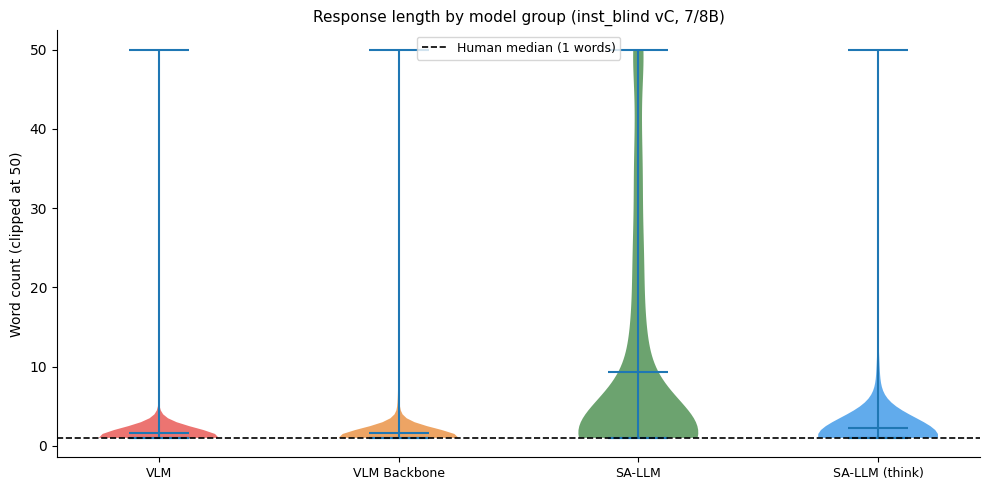

In [4]:
# Violin plot: word count by group + human baseline
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = []
for grp in GROUP_ORDER:
    sub = inst_blind[inst_blind['model_group'] == grp]
    if not sub.empty:
        plot_data.append(sub['word_count'].clip(upper=50))  # clip for visibility

parts = ax.violinplot(plot_data, positions=range(len(GROUP_ORDER)),
                      showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(GROUP_COLORS.get(GROUP_ORDER[i], '#888'))
    pc.set_alpha(0.7)

# Human baseline
ax.axhline(human_df['word_count'].median(), color='black', ls='--', lw=1.2,
           label=f'Human median ({human_df["word_count"].median():.0f} words)')

ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone')
                    for g in GROUP_ORDER], fontsize=9)
ax.set_ylabel('Word count (clipped at 50)', fontsize=10)
ax.set_title('Response length by model group (inst_blind vC, 7/8B)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'word_count_by_group')
plt.show()

## 3. Response length vs HM agreement

In [5]:
# Per question×model: mean HM metrics
METRICS = ['exact_score', 'jaccard_score', 'rouge1_score', 'chrf_score',
           'bertscore_f1', 'sbert_score', 'simcse_score']
METRIC_LABELS = ['Exact', 'Jaccard', 'ROUGE-1', 'chrF', 'BERTScore', 'SBERT', 'SimCSE']

hm_agg = hm.groupby(['question_id', 'subject_2'])[METRICS].mean().reset_index()
hm_agg = hm_agg.rename(columns={'subject_2': 'model'})

# Join with response length
merged = inst_blind[['question_id', 'model', 'model_group', 'resp_len', 'word_count']].merge(
    hm_agg, on=['question_id', 'model'], how='inner'
)
print(f'Merged: {len(merged)} rows')

# Correlation: word_count vs each metric, overall and per group
print('\n=== Pearson r: word_count vs HM metric ===')
print(f'{"Metric":<10} {"All":>8} ', end='')
for grp in GROUP_ORDER:
    print(f'{grp[:12]:>14}', end='')
print()

for m, ml in zip(METRICS, METRIC_LABELS):
    # All
    valid = merged.dropna(subset=[m, 'word_count'])
    r_all, p_all = stats.pearsonr(valid['word_count'], valid[m])
    sig_all = '***' if p_all < 0.001 else '**' if p_all < 0.01 else '*' if p_all < 0.05 else ''
    print(f'{ml:<10} {r_all:+.3f}{sig_all:<4s}', end='')
    for grp in GROUP_ORDER:
        sub = valid[valid['model_group'] == grp]
        if len(sub) > 5:
            r, p = stats.pearsonr(sub['word_count'], sub[m])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            print(f'{r:+.3f}{sig:<4s}      ', end='')
        else:
            print(f'{"N/A":>14}', end='')
    print()

KeyError: "Columns not found: 'exact_score', 'bertscore_f1', 'jaccard_score', 'simcse_score', 'rouge1_score'"

NameError: name 'merged' is not defined

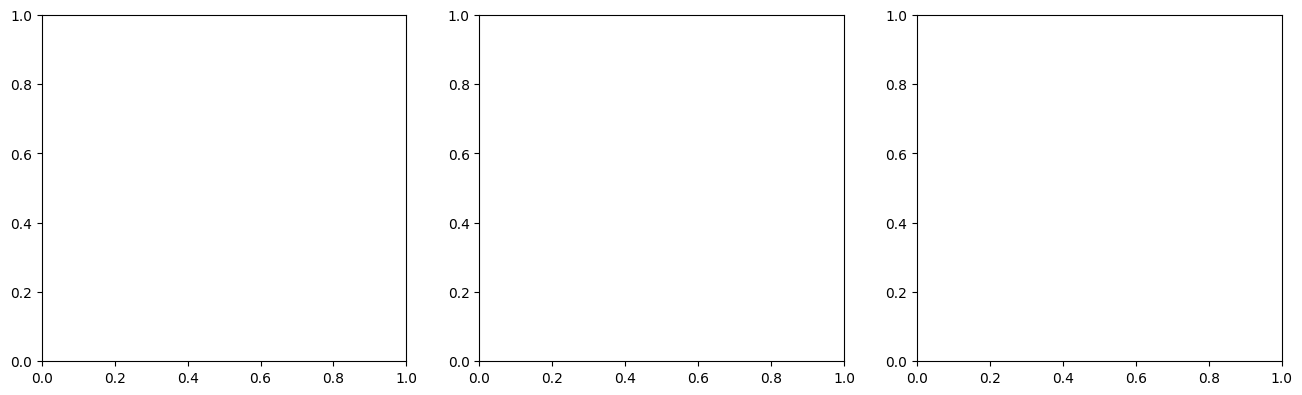

In [ ]:
# Scatter: word count vs SBERT and chrF, colored by group
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (mcol, mlabel) in zip(axes, [('sbert_score', 'SBERT'), ('chrf_score', 'chrF'),
                                      ('exact_score', 'Exact')]):
    for grp in GROUP_ORDER:
        sub = merged[merged['model_group'] == grp]
        color = GROUP_COLORS.get(grp, '#888')
        ax.scatter(sub['word_count'].clip(upper=50), sub[mcol],
                   alpha=0.2, s=12, color=color, edgecolors='none',
                   label=grp.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'BB'))
    
    # Human median word count reference
    ax.axvline(human_df['word_count'].median(), color='black', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Model response word count', fontsize=10)
    ax.set_ylabel(f'HM {mlabel}', fontsize=10)
    ax.set_title(mlabel, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].legend(fontsize=7.5, frameon=True, loc='upper right')
fig.suptitle('Response length vs Human-Model agreement (inst_blind vC, 7/8B)', fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'length_vs_hm_agreement')
plt.show()

## 4. Length-controlled comparison

Restrict to responses with word count in the "human-like" range (1-5 words, matching human VQA answer style). Do group differences persist?

In [6]:
# Human answer length profile
h_pct = human_df['word_count'].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print('Human word count percentiles:')
print(h_pct.to_string())

# Define "short" range: 1-5 words (covers ~75th percentile of human answers)
SHORT_MAX = 5
merged['is_short'] = merged['word_count'].between(1, SHORT_MAX)

print(f'\nShort responses (1-{SHORT_MAX} words) by group:')
short_rate = merged.groupby('model_group')['is_short'].mean()
for grp in GROUP_ORDER:
    r = short_rate.get(grp, 0)
    n = merged[merged['model_group'] == grp]['is_short'].sum()
    print(f'  {grp:<25s}: {r:.1%} ({n} responses)')

# HM agreement on short responses only
short_models = merged[merged['is_short']]
short_keys = set(zip(short_models['question_id'], short_models['model']))

hm_short = hm[hm.apply(lambda r: (r['question_id'], r['subject_2']) in short_keys, axis=1)]

KEY_M = ['exact_score', 'chrf_score', 'sbert_score', 'simcse_score']
KEY_L = ['Exact', 'chrF', 'SBERT', 'SimCSE']

grp_full  = hm.groupby('subject_group_2')[KEY_M].mean()
grp_short = hm_short.groupby('subject_group_2')[KEY_M].mean()

print(f'\n=== HM agreement: FULL vs SHORT-only (1-{SHORT_MAX} words) ===')
for grp in GROUP_ORDER:
    if grp not in grp_short.index:
        print(f'[{grp}] — insufficient short responses')
        continue
    print(f'[{grp}]')
    for m, ml in zip(KEY_M, KEY_L):
        f = grp_full.loc[grp, m]
        s = grp_short.loc[grp, m]
        print(f'  {ml:<8}  full={f:.3f}  short={s:.3f}  Δ={s-f:+.3f}')
    print()

# Gap comparison
print(f'── VLM ↔ SA-LLM gap: full vs short-only ──')
for m, ml in zip(KEY_M, KEY_L):
    vlm_f = grp_full.loc['VLM', m]
    sa_f  = grp_full.loc['standalone LLM', m]
    gap_f = vlm_f - sa_f
    if 'VLM' in grp_short.index and 'standalone LLM' in grp_short.index:
        vlm_s = grp_short.loc['VLM', m]
        sa_s  = grp_short.loc['standalone LLM', m]
        gap_s = vlm_s - sa_s
        print(f'  {ml:<8}  gap_full={gap_f:.3f}  gap_short={gap_s:.3f}')
    else:
        print(f'  {ml:<8}  gap_full={gap_f:.3f}  gap_short=N/A')

Human word count percentiles:
0.10    1.0
0.25    1.0
0.50    1.0
0.75    1.0
0.90    2.0


NameError: name 'merged' is not defined

NameError: name 'KEY_M' is not defined

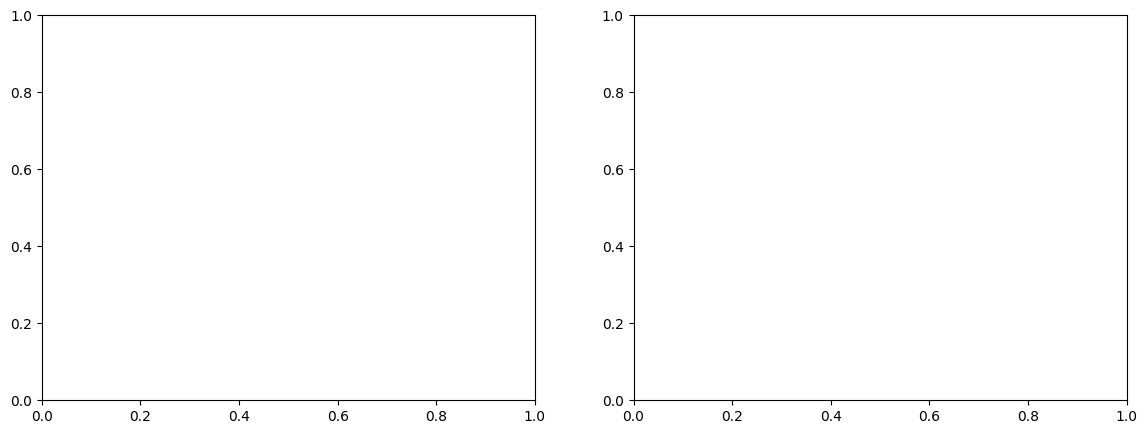

In [7]:
# Bar chart: full vs short-only, SBERT and chrF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hh_base = hh[KEY_M].mean()

for ax, (mcol, mlabel) in zip(axes, [('sbert_score', 'SBERT'), ('chrf_score', 'chrF')]):
    x = np.arange(len(GROUP_ORDER))
    w = 0.32
    colors = [GROUP_COLORS.get(g, '#888') for g in GROUP_ORDER]

    full_vals  = [grp_full.loc[g, mcol] if g in grp_full.index else 0 for g in GROUP_ORDER]
    short_vals = [grp_short.loc[g, mcol] if g in grp_short.index else 0 for g in GROUP_ORDER]

    ax.bar(x - w/2, full_vals, w * 0.9, color=colors, alpha=0.45,
           edgecolor='white', label='All responses')
    ax.bar(x + w/2, short_vals, w * 0.9, color=colors, alpha=0.95,
           edgecolor='white', label=f'Short only (1-{SHORT_MAX} words)')

    ax.axhline(hh_base[mcol], color='black', ls='--', lw=1.2,
               label=f'HH ceiling ({hh_base[mcol]:.3f})')

    ax.set_xticks(x)
    ax.set_xticklabels([g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone')
                        for g in GROUP_ORDER], fontsize=9, rotation=15, ha='right')
    ax.set_ylabel(f'Mean {mlabel}', fontsize=10)
    ax.set_title(f'{mlabel}: all vs short-answer responses', fontsize=11)
    ax.legend(fontsize=8, frameon=True)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Length bias check: HM agreement on short (1-{SHORT_MAX} word) responses only (7/8B, vC)',
             fontsize=11)
plt.tight_layout()
save_fig(fig, OUT_DIR, 'length_controlled_agreement')
plt.show()

## 5. Summary

In [8]:
print('Length bias analysis summary:')
print('─' * 50)
print()
for grp in GROUP_ORDER:
    sub = inst_blind[inst_blind['model_group'] == grp]
    print(f'{grp}:')
    print(f'  Median word count: {sub["word_count"].median():.0f}')
    print(f'  % short (1-{SHORT_MAX} words): {100*merged[merged["model_group"]==grp]["is_short"].mean():.0f}%')
    if grp in grp_short.index:
        print(f'  SBERT full→short: {grp_full.loc[grp, "sbert_score"]:.3f} → {grp_short.loc[grp, "sbert_score"]:.3f}')
    print()
print(f'Human median word count: {human_df["word_count"].median():.0f}')

Length bias analysis summary:
──────────────────────────────────────────────────

VLM:
  Median word count: 1


NameError: name 'merged' is not defined

## 6. Qwen3 Think vs Base by Scale (Output-Level Audit)

This section isolates Qwen3 `base` vs `think` behavior by parameter scale and condition.
We compare model outputs on shared `(question_id, variant)` rows and report:

- exact output match rate,
- response length expansion under `think`,
- per-variant exact-match rates,
- and example changed outputs when divergence exists.


In [9]:
from IPython.display import display

resp_inst = pd.read_csv(EXPORTS / "responses_model_inst_blind.csv")
resp_blind = pd.read_csv(EXPORTS / "responses_model_blind.csv")

QWEN3_SCALES = ["0.6B", "1.7B", "4B", "8B", "32B"]
PAIR_KEY = ["question_id", "variant"]


def _qwen3_scale_audit(resp_df: pd.DataFrame, condition_name: str):
    rows = []
    per_variant_rows = []

    for s in QWEN3_SCALES:
        base = f"Qwen3-{s}"
        think = f"Qwen3-{s} (think)"

        b = resp_df[resp_df["model"] == base][PAIR_KEY + ["response", "question_en"]].rename(
            columns={"response": "resp_base"}
        )
        t = resp_df[resp_df["model"] == think][PAIR_KEY + ["response"]].rename(
            columns={"response": "resp_think"}
        )

        m = b.merge(t, on=PAIR_KEY, how="inner")

        if m.empty:
            rows.append({
                "condition": condition_name,
                "scale": s,
                "shared_rows": 0,
                "exact_match_rate": np.nan,
                "changed_rows": 0,
                "mean_wc_base": np.nan,
                "mean_wc_think": np.nan,
                "median_wc_base": np.nan,
                "median_wc_think": np.nan,
            })
            continue

        m["same"] = (m["resp_base"].fillna("") == m["resp_think"].fillna(""))
        m["wc_base"] = m["resp_base"].fillna("").astype(str).str.split().str.len()
        m["wc_think"] = m["resp_think"].fillna("").astype(str).str.split().str.len()

        rows.append({
            "condition": condition_name,
            "scale": s,
            "shared_rows": int(len(m)),
            "exact_match_rate": float(m["same"].mean()),
            "changed_rows": int((~m["same"]).sum()),
            "mean_wc_base": float(m["wc_base"].mean()),
            "mean_wc_think": float(m["wc_think"].mean()),
            "median_wc_base": float(m["wc_base"].median()),
            "median_wc_think": float(m["wc_think"].median()),
        })

        by_var = m.groupby("variant", as_index=False).agg(
            shared_rows=("same", "size"),
            exact_match_rate=("same", "mean"),
            mean_wc_base=("wc_base", "mean"),
            mean_wc_think=("wc_think", "mean"),
        )
        by_var.insert(0, "scale", s)
        by_var.insert(0, "condition", condition_name)
        per_variant_rows.append(by_var)

    out = pd.DataFrame(rows)
    out["scale"] = pd.Categorical(out["scale"], categories=QWEN3_SCALES, ordered=True)
    out = out.sort_values("scale").reset_index(drop=True)

    out_var = pd.concat(per_variant_rows, ignore_index=True) if per_variant_rows else pd.DataFrame()
    if not out_var.empty:
        out_var["scale"] = pd.Categorical(out_var["scale"], categories=QWEN3_SCALES, ordered=True)
        out_var = out_var.sort_values(["scale", "variant"]).reset_index(drop=True)

    return out, out_var


audit_inst, audit_inst_var = _qwen3_scale_audit(resp_inst, "inst_blind")
audit_blind, audit_blind_var = _qwen3_scale_audit(resp_blind, "blind")
audit_all = pd.concat([audit_inst, audit_blind], ignore_index=True)

print("Qwen3 think-vs-base audit (shared rows only):")
display(audit_all)

print("\nPer-variant exact-match detail (first 20 rows):")
display(pd.concat([audit_inst_var, audit_blind_var], ignore_index=True).head(20))


Qwen3 think-vs-base audit (shared rows only):


,condition,scale,shared_rows,exact_match_rate,changed_rows,mean_wc_base,mean_wc_think,median_wc_base,median_wc_think
0,inst_blind,0.6B,336,1.000000,0,1.205357,1.205357,1.0,1.0
1,inst_blind,1.7B,338,0.130178,294,7.014793,210.769231,1.0,323.0
2,inst_blind,4B,339,1.000000,0,1.206490,1.206490,1.0,1.0
3,inst_blind,8B,339,1.000000,0,1.628319,1.628319,1.0,1.0
4,inst_blind,32B,338,0.186391,275,2.269231,228.659763,1.0,345.0
5,blind,0.6B,335,1.000000,0,1.098507,1.098507,1.0,1.0
6,blind,1.7B,338,1.000000,0,10.047337,10.047337,5.0,5.0
7,blind,4B,338,0.065089,316,1.381657,200.789941,1.0,317.0
8,blind,8B,338,1.000000,0,1.355030,1.355030,1.0,1.0
9,blind,32B,337,0.566766,146,2.661721,4.415430,1.0,1.0



Per-variant exact-match detail (first 20 rows):


,condition,scale,variant,shared_rows,exact_match_rate,mean_wc_base,mean_wc_think
0,inst_blind,0.6B,A,111,1.000000,1.288288,1.288288
1,inst_blind,0.6B,B,113,1.000000,1.230088,1.230088
2,inst_blind,0.6B,C,112,1.000000,1.098214,1.098214
3,inst_blind,1.7B,A,113,0.106195,5.672566,230.283186
4,inst_blind,1.7B,B,113,0.150442,7.548673,204.371681
5,inst_blind,1.7B,C,112,0.133929,7.830357,197.535714
6,inst_blind,4B,A,113,1.000000,1.132743,1.132743
7,inst_blind,4B,B,113,1.000000,1.185841,1.185841
8,inst_blind,4B,C,113,1.000000,1.300885,1.300885
9,inst_blind,8B,A,113,1.000000,1.371681,1.371681


Saved: /home/david/Desktop/yuna/HPA/figures/supplementary/length_bias/qwen3_think_vs_base_scale_audit


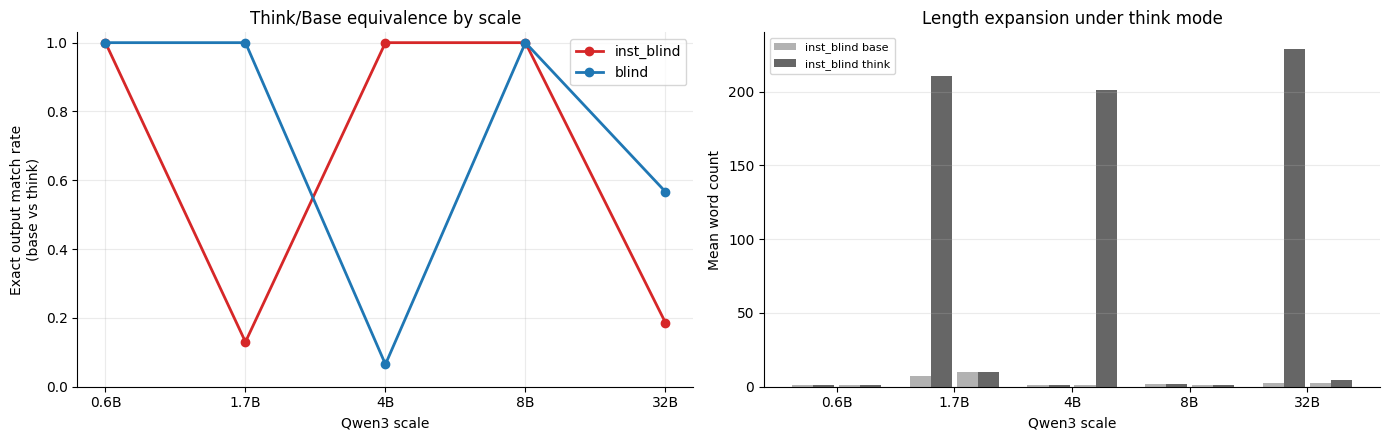

In [10]:
# Visual diagnostics: exact-match rate + length expansion by scale
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: exact output match rate by scale
for cond, c in [("inst_blind", "#d62728"), ("blind", "#1f77b4")]:
    sub = audit_all[audit_all["condition"] == cond].sort_values("scale")
    axes[0].plot(sub["scale"].astype(str), sub["exact_match_rate"], marker="o", lw=2, color=c, label=cond)

axes[0].set_ylim(0, 1.03)
axes[0].set_ylabel("Exact output match rate\n(base vs think)")
axes[0].set_xlabel("Qwen3 scale")
axes[0].set_title("Think/Base equivalence by scale")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: mean word count (base vs think)
x = np.arange(len(QWEN3_SCALES))
w = 0.18
for i, cond in enumerate(["inst_blind", "blind"]):
    sub = audit_all[audit_all["condition"] == cond].set_index("scale").reindex(QWEN3_SCALES)
    offset = (-0.5 + i) * (2 * w + 0.04)
    axes[1].bar(x + offset, sub["mean_wc_base"], width=w, color="#999999", alpha=0.75,
                label=f"{cond} base" if i == 0 else None)
    axes[1].bar(x + offset + w, sub["mean_wc_think"], width=w, color="#555555", alpha=0.9,
                label=f"{cond} think" if i == 0 else None)

axes[1].set_xticks(x + w / 2)
axes[1].set_xticklabels(QWEN3_SCALES)
axes[1].set_ylabel("Mean word count")
axes[1].set_xlabel("Qwen3 scale")
axes[1].set_title("Length expansion under think mode")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=True, fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_fig(fig, OUT_DIR, "qwen3_think_vs_base_scale_audit")
plt.show()


In [11]:
# Show concrete changed outputs for scales/conditions where base != think

def _sample_changes(resp_df: pd.DataFrame, condition_name: str, scale: str, n: int = 8):
    base = f'Qwen3-{scale}'
    think = f'Qwen3-{scale} (think)'

    b = resp_df[resp_df['model'] == base][PAIR_KEY + ['op', 'question_en', 'response']].rename(
        columns={'response': 'resp_base'}
    )
    t = resp_df[resp_df['model'] == think][PAIR_KEY + ['response']].rename(
        columns={'response': 'resp_think'}
    )

    m = b.merge(t, on=PAIR_KEY, how='inner')
    if m.empty:
        print(f'[{condition_name} | {scale}] no shared rows')
        return

    changed = m[m['resp_base'].fillna('') != m['resp_think'].fillna('')].copy()
    print(f'[{condition_name} | {scale}] changed rows: {len(changed)} / {len(m)}')
    if changed.empty:
        return

    show_cols = ['question_id', 'variant', 'op', 'question_en', 'resp_base', 'resp_think']
    display(changed[show_cols].head(n))

for cond_name, resp_df, scales in [
    ('inst_blind', resp_inst, ['1.7B', '32B']),
    ('blind', resp_blind, ['4B', '32B']),
]:
    for s in scales:
        _sample_changes(resp_df, cond_name, s, n=6)


[inst_blind | 1.7B] changed rows: 294 / 338


,question_id,variant,op,question_en,resp_base,resp_think
0,1342072,A,ident,What kind of information does it look like it ...,personal information,text
1,1342072,B,ident,What kind of information does the yellow and w...,collection of essays and articles,think okay let's see user is asking about what...
2,1342072,C,ident,What kind of information does the yellow and w...,guide to universe,think okay let's see user is asking about what...
4,2521002,B,spat,Which way is the indicator pointing?,to determine direction indicator is pointing w...,north
5,2521002,C,spat,Which way is the arrow pointing?,to determine direction arrow is pointing we wo...,north
6,9830000,A,attr,What type is it using?,rectangle,think okay let's see user is asking what type ...


[inst_blind | 32B] changed rows: 275 / 338


,question_id,variant,op,question_en,resp_base,resp_think
0,1342072,A,ident,What kind of information does it look like it ...,data,think okay let's tackle this question user wan...
1,1342072,B,ident,What kind of information does the yellow and w...,yellow pages directory,yellow pages directories
2,1342072,C,ident,What kind of information does the yellow and w...,phone directory or phone book,directory information
3,2521002,A,spat,Which way is it pointing?,north,think okay let's tackle this question: which w...
4,2521002,B,spat,Which way is the indicator pointing?,up,think okay let's tackle this question: which w...
5,2521002,C,spat,Which way is the arrow pointing?,up,think okay let's tackle this question: which w...


[blind | 4B] changed rows: 316 / 338


,question_id,variant,op,question_en,resp_base,resp_think
0,1342072,A,ident,What kind of information does it look like it ...,metadata,question using single word or phrase answer is...
1,1342072,B,ident,What kind of information does the yellow and w...,guidelines,directories
2,1342072,C,ident,What kind of information does the yellow and w...,guidelines,think okay user is asking what kind of informa...
3,2521002,A,spat,Which way is it pointing?,upward,think okay user is asking which way is it poin...
4,2521002,B,spat,Which way is the indicator pointing?,right,unknown
5,2521002,C,spat,Which way is the arrow pointing?,right,unknown


[blind | 32B] changed rows: 146 / 337


,question_id,variant,op,question_en,resp_base,resp_think
0,1342072,A,ident,What kind of information does it look like it ...,metadata,personal information
1,1342072,B,ident,What kind of information does the yellow and w...,classified advertisements,government information or official documents
2,1342072,C,ident,What kind of information does the yellow and w...,travel information,phone directory information
4,2521002,B,spat,Which way is the indicator pointing?,upward,right
6,9830000,A,attr,What type is it using?,question is incomplete and lacks context regar...,question is incomplete and lacks context so it...
9,13546003,A,count,How many are in the background?,background,background:


## 7. Thinking Trace vs Final Answer Length (Thinking LLMs Only)

This section measures the raw saved output format for the Qwen3 thinking LLMs only. We separate:
- `think_words`: words inside `<think>...</think>`,
- `final_words`: words after `</think>`,
- `total_words`: full saved response length.

This is computed from the raw inference JSONL files, not the cleaned export tables, so it reflects what the inference pipeline actually saved.


In [12]:
import json, re
from pathlib import Path

try:
    ROOT
except NameError:
    ROOT = Path.cwd()

THINK_MODELS = ['Qwen3-0.6B_think', 'Qwen3-1.7B_think', 'Qwen3-4B_think', 'Qwen3-8B_think', 'Qwen3-32B_think']
THINK_CONDS = ['blind', 'inst_blind']
THINK_PAT = re.compile(r'^<think>(.*?)</think>\s*(.*)$', re.S)

def split_think_answer(ans: str):
    ans = '' if ans is None else str(ans)
    m = THINK_PAT.match(ans)
    if m:
        think = m.group(1).strip()
        final = m.group(2).strip()
        return True, think, final
    return False, '', ans.strip()

trace_rows = []
for model in THINK_MODELS:
    for cond in THINK_CONDS:
        path = ROOT / 'evaluation' / 'logits' / 'backbone' / 'pretrained' / model / f'vqa_1k_control_{cond}.jsonl'
        if not path.exists():
            continue
        with open(path, encoding='utf-8') as f:
            for line in f:
                ex = json.loads(line)
                qid = ex['question_id']
                for variant, ans in (ex.get('generated_answers') or {}).items():
                    has_tag, think, final = split_think_answer(ans)
                    trace_rows.append({
                        'model_dir': model,
                        'condition': cond,
                        'question_id': qid,
                        'variant': variant,
                        'has_think_tag': has_tag,
                        'think_nonempty': bool(think),
                        'think_text': think,
                        'final_text': final,
                        'raw_text': '' if ans is None else str(ans),
                        'think_words': len(think.split()),
                        'final_words': len(final.split()),
                        'total_words': len(str(ans).split()),
                    })

trace_df = pd.DataFrame(trace_rows)
trace_df['model'] = trace_df['model_dir'].str.replace('_think', ' (think)', regex=False)
trace_df['scale'] = trace_df['model'].str.extract(r'Qwen3-(.*) \(think\)')
trace_df['scale_num'] = trace_df['scale'].str.replace('B', '', regex=False).astype(float)
print(f'Loaded {len(trace_df):,} raw think-model answers')
display(trace_df[['model', 'condition', 'question_id', 'variant', 'think_words', 'final_words', 'total_words']].head())


NameError: name 'BASE' is not defined

In [13]:
trace_summary = (
    trace_df.groupby(['model', 'condition'], as_index=False)
    .agg(
        answers=('raw_text', 'size'),
        think_tag_rate=('has_think_tag', 'mean'),
        nonempty_think_rate=('think_nonempty', 'mean'),
        think_words_mean=('think_words', 'mean'),
        think_words_median=('think_words', 'median'),
        final_words_mean=('final_words', 'mean'),
        final_words_median=('final_words', 'median'),
        total_words_mean=('total_words', 'mean'),
        total_words_median=('total_words', 'median'),
    )
)
trace_summary['scale_num'] = trace_summary['model'].str.extract(r'Qwen3-(.*) \(think\)').iloc[:, 0].str.replace('B', '', regex=False).astype(float)
trace_summary = trace_summary.sort_values(['condition', 'scale_num'])
trace_summary['think_tag_rate'] *= 100
trace_summary['nonempty_think_rate'] *= 100
display(trace_summary.round(2))

print('Condition-level interpretation:')
for cond in THINK_CONDS:
    sub = trace_summary[trace_summary['condition'] == cond]
    print(f'[{cond}]')
    for _, r in sub.iterrows():
        print(f"  {r['model']}: nonempty think {r['nonempty_think_rate']:.1f}% | think mean {r['think_words_mean']:.1f}w | final mean {r['final_words_mean']:.1f}w")
    print()


NameError: name 'trace_df' is not defined

NameError: name 'trace_summary' is not defined

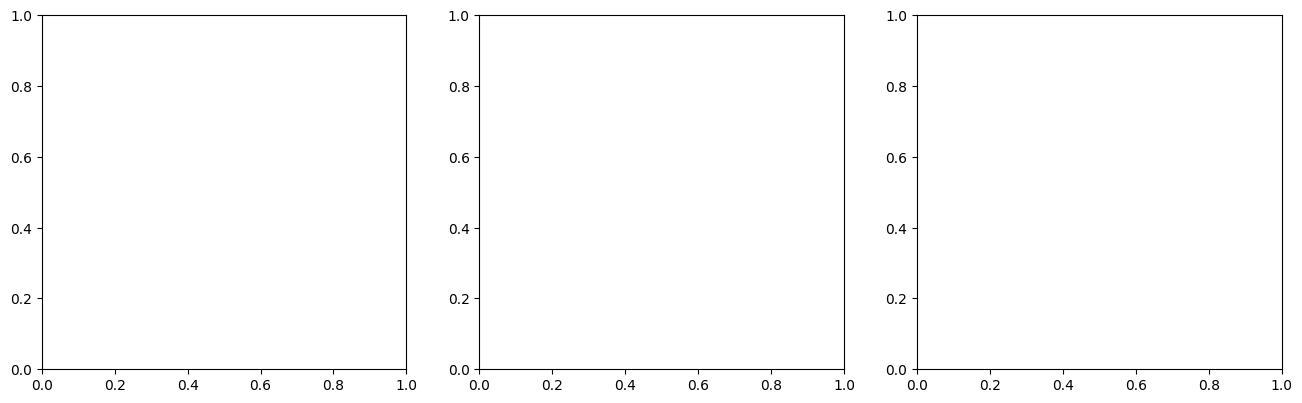

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
cond_colors = {
    'trace': '#4C78A8',
    'final': '#F58518',
}

for ax, cond in zip(axes, THINK_CONDS):
    sub = trace_summary[trace_summary['condition'] == cond].sort_values('scale_num').copy()
    x = np.arange(len(sub))
    w = 0.36

    ax.bar(x - w/2, sub['think_words_mean'], width=w, color=cond_colors['trace'], label='Think trace')
    ax.bar(x + w/2, sub['final_words_mean'], width=w, color=cond_colors['final'], label='Final answer')

    for xi, trace_h, pct in zip(x, sub['think_words_mean'], sub['nonempty_think_rate']):
        ax.text(xi - w/2, trace_h + max(1.5, 0.02 * max(sub['think_words_mean'].max(), 1)),
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=9, color=cond_colors['trace'])

    ax.set_title(cond.replace('_', ' '))
    ax.set_xticks(x)
    ax.set_xticklabels(sub['scale'].tolist())
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('Mean words')
axes[0].legend(frameon=False, ncol=2, loc='upper left')
plt.suptitle('Qwen3 think models: trace length vs final-answer length
Trace bars annotated with % non-empty think traces', y=1.05, fontsize=13)
plt.tight_layout()
plt.show()


In [15]:
def show_trace_examples(condition_name: str, model_name: str, n: int = 4):
    sub = trace_df[(trace_df['condition'] == condition_name) & (trace_df['model'] == model_name)].copy()
    print(f'=== {model_name} | {condition_name} ===')

    long_trace = sub[sub['think_words'] > 0][['question_id', 'variant', 'think_words', 'final_words', 'think_text', 'final_text']].head(n)
    if len(long_trace):
        print('Non-empty think samples:')
        display(long_trace)
    else:
        print('No non-empty think traces in this slice.')

    empty_tag = sub[(sub['has_think_tag']) & (~sub['think_nonempty'])][['question_id', 'variant', 'final_words', 'final_text']].head(n)
    if len(empty_tag):
        print('Empty-think-tag samples:')
        display(empty_tag)
    print()

show_trace_examples('inst_blind', 'Qwen3-1.7B (think)')
show_trace_examples('blind', 'Qwen3-4B (think)')
show_trace_examples('inst_blind', 'Qwen3-8B (think)')
show_trace_examples('inst_blind', 'Qwen3-32B (think)')


NameError: name 'trace_df' is not defined